Using device: cpu
Number of classes: 120
Found 1000 labeled images in train folder.
Train size: 800 Valid size: 200
Number of classes: 120
FinetuneResNet(
  (features): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64

/Users/kasidischuayprasert/Desktop/MachineLearning/JupyterDeepLearning/.conda/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1/10 - 53.4s - Train Loss: 4.4788 Acc: 0.0900 - Val Loss: 3.1953 Acc: 0.3050
Epoch 2/10 - 49.7s - Train Loss: 2.6398 Acc: 0.3725 - Val Loss: 1.8295 Acc: 0.5650
Epoch 3/10 - 49.3s - Train Loss: 1.7167 Acc: 0.5475 - Val Loss: 1.4326 Acc: 0.5800
Epoch 4/10 - 50.7s - Train Loss: 1.2320 Acc: 0.6687 - Val Loss: 1.2572 Acc: 0.6100
Epoch 5/10 - 49.8s - Train Loss: 1.0399 Acc: 0.7063 - Val Loss: 1.4156 Acc: 0.5950
Epoch 6/10 - 49.7s - Train Loss: 0.9961 Acc: 0.7188 - Val Loss: 1.2910 Acc: 0.6250
Epoch 7/10 - 54.7s - Train Loss: 0.8752 Acc: 0.7675 - Val Loss: 1.2729 Acc: 0.6250
Epoch 8/10 - 50.1s - Train Loss: 0.8728 Acc: 0.7438 - Val Loss: 1.2536 Acc: 0.6750
Epoch 9/10 - 52.9s - Train Loss: 0.8103 Acc: 0.7725 - Val Loss: 1.2312 Acc: 0.6500
Epoch 10/10 - 49.9s - Train Loss: 0.7364 Acc: 0.8175 - Val Loss: 1.3276 Acc: 0.6700
Saved best weights to: runs/pose/train/weights/best_Dog.pt
Test Loss: 1.3276, Test Top-1 Accuracy: 0.6700


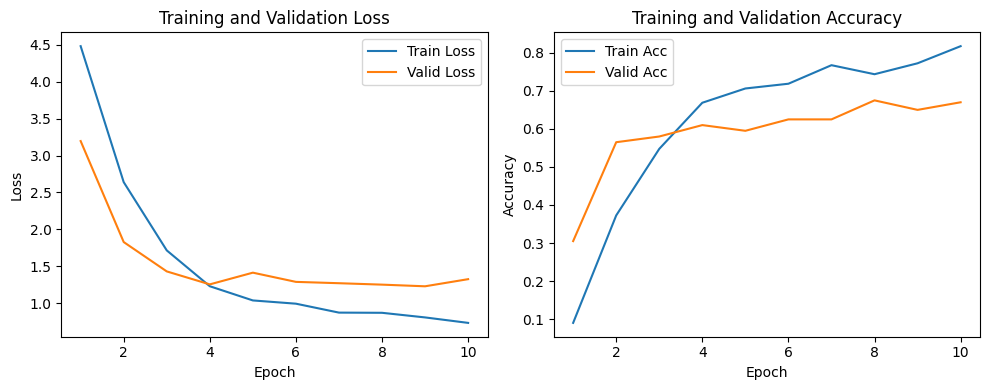

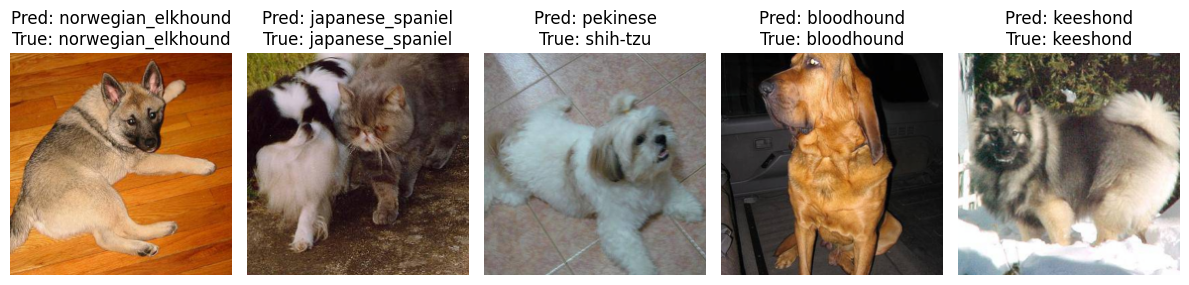

In [5]:
import os
import time
import numpy as np
import pandas as pd              # Used for reading labels.csv
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


# ----------------------------------------------------------
# 1) MAIN DATASET PATHS
# ----------------------------------------------------------

data_dir = "kaggle_dog_tiny"      # Root folder of your dataset
train_dir = os.path.join(data_dir, "train")   # Training images (with labels in labels.csv)
test_dir  = os.path.join(data_dir, "test")    # Test images (if labeled, they should appear in csv)

labels_path = os.path.join(data_dir, "labels.csv")  # Path to labels.csv file

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
devices = [device]
print("Using device:", device)


# ----------------------------------------------------------
# 2) Read labels.csv and create mappings
# ----------------------------------------------------------

# labels.csv contains columns: id, breed  e.g.
# 0097c6...,bedlington_terrier
df = pd.read_csv(labels_path)                # Read the CSV file
df["filename"] = df["id"].astype(str) + ".jpg"  # Append ".jpg" to create filename

# Assume all rows in labels.csv belong to images in the train folder
# If some are in test, separate them by filename

# Create a list of all unique breeds and build mappings
breed_names = sorted(df["breed"].unique().tolist())
breed_to_idx = {b: i for i, b in enumerate(breed_names)}
idx_to_breed = {i: b for b, i in breed_to_idx.items()}

num_classes = len(breed_names)
print("Number of classes:", num_classes)


# ----------------------------------------------------------
# 3) Image transforms
# ----------------------------------------------------------

mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])


# ----------------------------------------------------------
# 4) Custom Dataset using folder + labels.csv
# ----------------------------------------------------------

class DogDataset(Dataset):
    def __init__(self, root_dir, df, transform=None):
        """
        root_dir: directory with image files (e.g. kaggle_dog_tiny/train)
        df      : DataFrame containing columns filename, breed
        transform: torchvision.transforms for preprocessing
        """
        self.root_dir = root_dir
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        # Total number of samples = number of DataFrame rows
        return len(self.df)

    def __getitem__(self, idx):
        # Get the row with index idx
        row = self.df.iloc[idx]

        # Build the image path, e.g. train/0a7f8d....jpg
        fname = row["filename"]
        img_path = os.path.join(self.root_dir, fname)

        # Open image and convert to RGB
        image = Image.open(img_path).convert("RGB")

        # Get breed name (e.g. "pug") and map to index
        breed_name = row["breed"]
        label = breed_to_idx[breed_name]

        # Apply transform if given
        if self.transform is not None:
            image = self.transform(image)

        # Return image tensor and label index
        return image, label


# ----------------------------------------------------------
# 5) Split TRAIN / VALID from csv (using train_dir)
# ----------------------------------------------------------

# Ensure all files in df exist within train_dir
df["exists_in_train"] = df["filename"].apply(lambda f: os.path.exists(os.path.join(train_dir, f)))
df_train_all = df[df["exists_in_train"]].copy()

print("Found", len(df_train_all), "labeled images in train folder.")

# Split 80% train / 20% validation, stratified by breed
train_df, valid_df = train_test_split(
    df_train_all,
    test_size=0.2,
    stratify=df_train_all["breed"],
    random_state=42
)

print("Train size:", len(train_df), "Valid size:", len(valid_df))

train_dataset = DogDataset(train_dir, train_df, transform=train_transforms)
valid_dataset = DogDataset(train_dir, valid_df, transform=test_transforms)

# If test_dir has no labeled data, use valid_dataset for testing temporarily
test_dataset = valid_dataset


# ----------------------------------------------------------
# 6) DataLoader
# ----------------------------------------------------------

batch_size = 32
num_workers = 0

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=True)

# Get class names from train_dataset
class_names = breed_names
# Count number of classes (should be 120 for Stanford Dogs)
num_classes = len(class_names)
print("Number of classes:", num_classes)


# ----------------------------------------------------------
# 1. Create model according to get_net from assignment
# ----------------------------------------------------------

def get_net(devices):
    """
    This function builds the fine-tuned ResNet34 model:
    - Use ResNet34 as feature extractor (features)
    - Keep the original fully-connected layer (512 -> 1000) as old_fc
    - Add a new head (1000 -> 256 -> num_classes)
    - Freeze feature extractor parameters (requires_grad=False)
    """
    class FinetuneResNet(nn.Module):
        def __init__(self, num_classes):
            super().__init__()

            # Load pretrained ResNet34 on ImageNet
            self.features = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)

            # The original fc layer: Linear(512 -> 1000)
            self.old_fc = self.features.fc

            # Replace the original fc layer with Identity
            # So self.features(x) outputs a 512-dim feature from global avg pool
            self.features.fc = nn.Identity()

            # Build new head: Linear(1000 -> 256) + ReLU + Linear(256 -> num_classes)
            self.output_new = nn.Sequential(
                nn.Linear(1000, 256),
                nn.ReLU(),
                nn.Linear(256, num_classes)
            )

        def forward(self, x):
            """
            x: [batch_size, 3, 224, 224]
            Forward process:
            1) self.features(x): get 512-dim feature vector
            2) self.old_fc: fc(512->1000) gives logits of size [batch,1000]
            3) self.output_new: head for classification to 120 classes
            Output logits are not softmaxed (CrossEntropyLoss handles that)
            """
            feats_512 = self.features(x)
            feats_1000 = self.old_fc(feats_512)
            output = self.output_new(feats_1000)
            return output

    finetune_net = FinetuneResNet(num_classes).to(devices[0])

    # Freeze the backbone parameters (features)
    for param in finetune_net.features.parameters():
        param.requires_grad = False

    return finetune_net


# Instantiate the model
model = get_net(devices)

# Print model summary
print(model)


# ----------------------------------------------------------
# 2. Define loss function and optimizer
# ----------------------------------------------------------

# CrossEntropyLoss computes:
# 1) softmax: p_k = exp(z_k) / sum_j exp(z_j)
# 2) loss = -log(p_y) for true class y
criterion = nn.CrossEntropyLoss()

# Use Adam optimizer (lr = 0.001)
# Adam updates parameters using running averages of gradients (m_t)
# and their squares (v_t):
#   m_t = β1 * m_{t-1} + (1-β1) * g_t
#   v_t = β2 * v_{t-1} + (1-β2) * (g_t^2)
#   w_t = w_{t-1} - η * m_t / (sqrt(v_t) + ε)
# This accelerates convergence and adapts learning rates per parameter.
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

num_epochs = 10


# ----------------------------------------------------------
# 3. Train one epoch and evaluation functions
# ----------------------------------------------------------

def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Train the model for one epoch:
    - Forward -> compute loss -> backward -> optimizer.step()
    - Track average loss and accuracy
    """
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels).item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    """
    Evaluate model on validation/test set:
    - Disable learning (no_grad)
    - Compute loss and accuracy
    """
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels).item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc


# ----------------------------------------------------------
# 4. Training loop
# ----------------------------------------------------------

train_losses, valid_losses = [], []
train_accs, valid_accs = [], []

best_valid_acc = 0.0
best_model_wts = None

for epoch in range(num_epochs):
    since = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    valid_loss, valid_acc = evaluate(model, valid_loader, criterion, device)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    train_accs.append(train_acc)
    valid_accs.append(valid_acc)

    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        best_model_wts = model.state_dict()

    time_elapsed = time.time() - since
    print(f"Epoch {epoch+1}/{num_epochs} "
          f"- {time_elapsed:.1f}s "
          f"- Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} "
          f"- Val Loss: {valid_loss:.4f} Acc: {valid_acc:.4f}")

if best_model_wts is not None:
    model.load_state_dict(best_model_wts)
    save_path = "runs/pose/train/weights/best_Dog.pt"
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    torch.save(model.state_dict(), save_path)
    print("Saved best weights to:", save_path)


# ----------------------------------------------------------
# 5. Evaluation on test set (Top-1 Accuracy)
# ----------------------------------------------------------

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}, Test Top-1 Accuracy: {test_acc:.4f}")
# Top-1 Accuracy = proportion where argmax(logit) == true label


# ----------------------------------------------------------
# 6. Plot Loss / Accuracy over epochs
# ----------------------------------------------------------

epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(10, 4))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, valid_losses, label="Valid Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accs, label="Train Acc")
plt.plot(epochs_range, valid_accs, label="Valid Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# 7. Display 5 sample predictions from the test set
# ----------------------------------------------------------

def imshow(inp, title=None):
    """
    Helper function to display image from tensor:
    - inp: tensor [C,H,W]
    - undo normalize: x = x * std + mean
    - convert to (H,W,C) and plot with matplotlib
    """
    inp = inp.cpu().numpy().transpose((1, 2, 0))
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')


model.eval()

dataiter = iter(test_loader)
images, labels = next(dataiter)

images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

plt.figure(figsize=(12, 6))
for i in range(5):
    ax = plt.subplot(1, 5, i + 1)
    imshow(images[i],
           title=f"Pred: {class_names[preds[i].item()]}\nTrue: {class_names[labels[i].item()]}")
plt.tight_layout()
plt.show()


# TEST CODE

In [20]:
import pandas as pd
import numpy as np

df = pd.read_csv("kaggle_dog_tiny/labels.csv")
breed_names = sorted(df["breed"].unique().tolist())
np.save("kaggle_dog_tiny/breed_names.npy", np.array(breed_names))

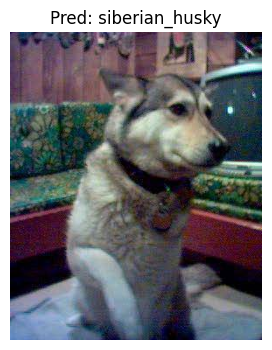

Pred : siberian_husky


In [2]:
import torch
from torchvision import transforms, models
from torch import nn
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# ----- ใช้ค่าเดียวกับตอนเทรน -----
num_classes = 120
device = torch.device("cpu")
devices = [device]

# นำเข้าหรือกำหนด class_names ให้ตรงกับตอนเทรน
# ตัวอย่าง: from train_file import breed_names as class_names
breed_names = np.load("kaggle_dog_tiny/breed_names.npy").tolist()
class_names = breed_names    # ถ้าเขียนอยู่ไฟล์เดียวกัน

# ---------- 1) โมเดลเดิมจาก get_net ----------

def get_net(devices):
    class FinetuneResNet(nn.Module):
        def __init__(self, num_classes):
            super().__init__()
            self.features = models.resnet34(
                weights=models.ResNet34_Weights.IMAGENET1K_V1
            )
            self.old_fc = self.features.fc
            self.features.fc = nn.Identity()
            self.output_new = nn.Sequential(
                nn.Linear(1000, 256),
                nn.ReLU(),
                nn.Linear(256, num_classes)
            )

        def forward(self, x):
            feats_512 = self.features(x)
            feats_1000 = self.old_fc(feats_512)
            output = self.output_new(feats_1000)
            return output

    net = FinetuneResNet(num_classes)
    net = net.to(devices[0])
    for p in net.features.parameters():
        p.requires_grad = False
    return net

# ---------- 2) โหลด weight ที่เซฟไว้ ----------

model = get_net(devices)
model.load_state_dict(torch.load(
    "runs/pose/train/weights/best_Dog.pt", map_location=device
))
model.eval()

# ---------- 3) transform ให้ตรงตอนเทรน (ใช้ test_transforms) ----------

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ---------- 4) เทสรูปเดียว ----------

img_path = "kaggle_dog_tiny/test/b2f350d68b6264610c176e150dabc950.jpg"
# true_label = "-"       # ไม่มี label จริงใน test ก็ใส่ขีดไว้ได้

img = Image.open(img_path).convert("RGB")
x = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(x)
    pred_idx = outputs.argmax(dim=1).item()

pred_label = class_names[pred_idx]

# ---------- 5) แสดงผล ----------

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title(f"Pred: {pred_label}")
plt.show()

print("Pred :", pred_label)
# print("True :", true_label)
# print("Match:", pred_label == true_label)


In [ ]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
from torch import nn
from torchvision import models, transforms
from PIL import Image


# ---------- PATH CONFIG ----------

TRAIN_DIR = "kaggle_dog_tiny/train"
LABEL_CSV = "kaggle_dog_tiny/labels.csv"
BREED_NAMES_NPY = "kaggle_dog_tiny/breed_names.npy"
MODEL_WEIGHTS = "runs/pose/train/weights/best_Dog.pt"
FACE_CASCADE_PATH = "haarcascade_frontalface_default.xml"

num_classes = 120
device = torch.device("cpu")      # หรือ torch.device("cuda")
devices = [device]


# ---------- CLASS NAMES ----------

breed_names = np.load(BREED_NAMES_NPY).tolist()
class_names = breed_names


# ---------- map class_idx -> train image ----------

df = pd.read_csv(LABEL_CSV)   # columns: id, breed

breed_to_id = {}
for _, row in df.iterrows():
    b = row["breed"]
    if b in class_names and b not in breed_to_id:
        breed_to_id[b] = row["id"]

class_idx_to_example_path = {}
for idx, breed in enumerate(class_names):
    img_id = breed_to_id.get(breed)
    if img_id is None:
        continue
    path = os.path.join(TRAIN_DIR, f"{img_id}.jpg")
    if os.path.exists(path):
        class_idx_to_example_path[idx] = path


# ---------- MODEL ----------

def get_net(devices):
    class FinetuneResNet(nn.Module):
        def __init__(self, num_classes):
            super().__init__()
            self.features = models.resnet34(
                weights=models.ResNet34_Weights.IMAGENET1K_V1
            )
            self.old_fc = self.features.fc
            self.features.fc = nn.Identity()
            self.output_new = nn.Sequential(
                nn.Linear(1000, 256),
                nn.ReLU(),
                nn.Linear(256, num_classes)
            )

        def forward(self, x):
            feats_512 = self.features(x)
            feats_1000 = self.old_fc(feats_512)
            output = self.output_new(feats_1000)
            return output

    net = FinetuneResNet(num_classes)
    net = net.to(devices[0])
    for p in net.features.parameters():
        p.requires_grad = False
    return net


model = get_net(devices)
state_dict = torch.load(MODEL_WEIGHTS, map_location=device)
model.load_state_dict(state_dict)
model.eval()


# ---------- TRANSFORM ----------

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])


def preprocess_bgr_image(img_bgr):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(img_rgb)
    x = transform(img_pil).unsqueeze(0).to(device)
    return x


# ---------- THUMBNAIL HELPERS ----------

THUMB_SIZE = (220, 220)   # ขยาย thumbnail หน้าและหมาให้ใหญ่ขึ้น

def load_dog_thumb_by_idx(class_idx, size=THUMB_SIZE):
    path = class_idx_to_example_path.get(class_idx)
    if path is None or not os.path.exists(path):
        return None
    img = cv2.imread(path)
    if img is None:
        return None
    thumb = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
    return thumb


def resize_face_thumb(face_roi, size=THUMB_SIZE):
    return cv2.resize(face_roi, size, interpolation=cv2.INTER_AREA)


def overlay_at(frame, thumb, x, y):
    """
    วาง thumb (BGR) ที่ตำแหน่ง (x, y) = มุมซ้ายบน บน frame (BGR)
    ถ้าล้นจอจะ crop ให้พอดี
    """
    fh, fw, _ = frame.shape
    th, tw, _ = thumb.shape

    if x >= fw or y >= fh:
        return frame

    x2 = min(x + tw, fw)
    y2 = min(y + th, fh)

    thumb_x2 = x2 - x
    thumb_y2 = y2 - y

    if thumb_x2 <= 0 or thumb_y2 <= 0:
        return frame

    frame[y:y2, x:x2] = thumb[0:thumb_y2, 0:thumb_x2]
    return frame


# ---------- FACE CASCADE ----------

face_cascade = cv2.CascadeClassifier(FACE_CASCADE_PATH)
if face_cascade.empty():
    raise RuntimeError(f"Cannot load face cascade from {FACE_CASCADE_PATH}")


# ---------- WEBCAM LOOP (MULTI-FACE + THUMB ต่อคน) ----------

def run_webcam():
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        raise RuntimeError("Cannot open webcam")

    dog_thumb_cache = {}

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(60, 60)
        )

        for (x, y, w, h) in faces:
            face_roi = frame[y:y+h, x:x+w]

            # ทำนายหมาสำหรับใบหน้านี้
            x_tensor = preprocess_bgr_image(face_roi)
            with torch.no_grad():
                outputs = model(x_tensor)
                pred_idx = outputs.argmax(dim=1).item()
            pred_label = class_names[pred_idx]

            # วาดกรอบหน้า
            cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 255), 2)

            # เขียนชื่อหมาเหนือกรอบ
            cv2.putText(
                frame,
                pred_label,
                (x, max(y-10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 255),
                2,
                cv2.LINE_AA
            )

            # thumbnail หน้า (ขยาย)
            face_thumb = resize_face_thumb(face_roi, THUMB_SIZE)

            # thumbnail หมา (ขยาย)
            if pred_idx in dog_thumb_cache:
                dog_thumb = dog_thumb_cache[pred_idx]
            else:
                dog_thumb = load_dog_thumb_by_idx(pred_idx, THUMB_SIZE)
                dog_thumb_cache[pred_idx] = dog_thumb

            # วาง thumbnail หน้า + หมา ข้าง ๆ กรอบแต่ละคน
            # ตัวอย่าง: วางด้านขวาของกรอบ ถ้าล้นให้เลื่อนไปซ้าย
            if dog_thumb is not None:
                # เริ่มวางจากขวาของกรอบ
                base_x = x + w + 10
                base_y = y

                # ถ้าล้นขวา ให้ย้ายไปด้านซ้ายของกรอบ
                fh, fw, _ = frame.shape
                if base_x + THUMB_SIZE[0]*2 + 10 > fw:
                    base_x = max(x - THUMB_SIZE[0]*2 - 20, 0)

                # วางรูปหน้า
                frame = overlay_at(frame, face_thumb, base_x, base_y)

                # วางรูปหมา ถัดไปทางขวา
                frame = overlay_at(frame, dog_thumb,
                                   base_x + THUMB_SIZE[0] + 10,
                                   base_y)

        cv2.imshow("Multi Face -> Dog Breed (thumb per person, press q to quit)", frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()


if __name__ == "__main__":
    run_webcam()


2025-12-24 19:28:24.024 python[15211:692040] WARNING: AVCaptureDeviceTypeExternal is deprecated for Continuity Cameras. Please use AVCaptureDeviceTypeContinuityCamera and add NSCameraUseContinuityCameraDeviceType to your Info.plist.


KeyboardInterrupt: 

: 